# Lab 3 - Part 1: Text Visualization & Classical Representations


**Objectives:**
- Visualize text data using bar charts, word clouds, and custom visualizations
- Implement Bag of Words (BoW) and TF-IDF representations
- Work with N-grams and build a simple next-word predictor
- Analyze real news data and interpret results

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning
- Will be verified during an **oral defense session**

---

## Setup

In [44]:
# Install required libraries (uncomment if needed)
# !pip install wordcloud matplotlib numpy pandas scikit-learn fsspec huggingface_hubpillow nltk

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


---

## Part A: Loading and Exploring the 20 Newsgroups Dataset (15 min)

We will use the 20 Newsgroups dataset from Hugging Face. This dataset contains news articles from 20 different categories.

In [46]:
# Load the dataset
import pandas as pd
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
## TODO: check on https://huggingface.co/datasets/SetFit/20_newsgroups how to load with pandas
from datasets import load_dataset

dataset = load_dataset("SetFit/20_newsgroups")

# Convert to pandas
df = pd.DataFrame(dataset['train'])

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())

Repo card metadata block was not found. Setting CardData to empty.


Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
sci.med                     594
rec.autos                   594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [47]:
# View sample data
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Select YOUR Categories

**Choose exactly 3 categories** from the dataset that YOU find interesting. This choice is personal and will affect all your subsequent analysis.

**Available categories:**
- alt.atheism, comp.graphics, ...

In [48]:
# TODO: Choose YOUR 3 categories (this affects all your analysis!)
# YOUR CODE HERE
my_categories = ["sci.space", "rec.sport.baseball", "talk.politics.guns"] # Replace with your choices

# Filter the dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['sci.space', 'rec.sport.baseball', 'talk.politics.guns']
Filtered dataset size: 1736

Distribution:
label_text
rec.sport.baseball    597
sci.space             593
talk.politics.guns    546
Name: count, dtype: int64


### Written Question A.1 (Personal Interpretation)

**Why did you choose these 3 specific categories?** Explain your reasoning (at least 3 sentences).

Consider:
- Are they related or completely different?
- What do you expect to find in terms of vocabulary differences?
- Why are they interesting to YOU?

**YOUR ANSWER:**

*[Write your answer here - minimum 3 sentences]*
I opted for the three categories to study because of their different fields; they include science, sports, and politics. Hence, I will be able to compare the different types of vocabulary and themes presented in each category.

I expect the sci.space category to have a high proportion of technical and scientific vocabulary, while there will be sports-related vocabulary in the rec.sport.baseball category. In contrast, there will be more argumentative and opinionated language in the talk.politics.guns category.

The categories represent how people actually discuss these topics in their communities; therefore I find it interesting to see how the results can be compared across multiple contexts.

...

---

## Part B: Text Preprocessing Function

Before visualization, we need to clean our text data.

In [49]:
# Example preprocessing function
# TODO: Complete the function as needed
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)  # remove emails
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'\d+', '', text)      # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


### Exercise B.1: Improve the Preprocessing Function

The function above is basic. **Improve it** by adding:
1. Stop word removal
2. Lemmatization
3. Minimum word length filter (remove words with < 3 characters)

In [50]:

import nltk
import re
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

# Download required resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')  # <-- FIX

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {
        "J": wordnet.ADJ,
        "N": wordnet.NOUN,
        "V": wordnet.VERB,
        "R": wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)

def preprocess_text_advanced(text):
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens]
    tokens = [word for word in tokens if len(word) >= 3]

    return ' '.join(tokens)

# TEST
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print("Original:", sample)
print("Processed:", preprocess_text_advanced(sample))

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Processed: cat run quickly towards beautiful garden email


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [51]:
# Apply preprocessing to your filtered dataset
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
article tom baker understand expect error basically know bug warn system software thing checked dont right value yet arent set till launch suchlike rather fix code possibly introduce new bug tell crew see warn liftoff ignore


---

## Part C: Text Visualization

### C.1 Bar Chart: Top Words per Category

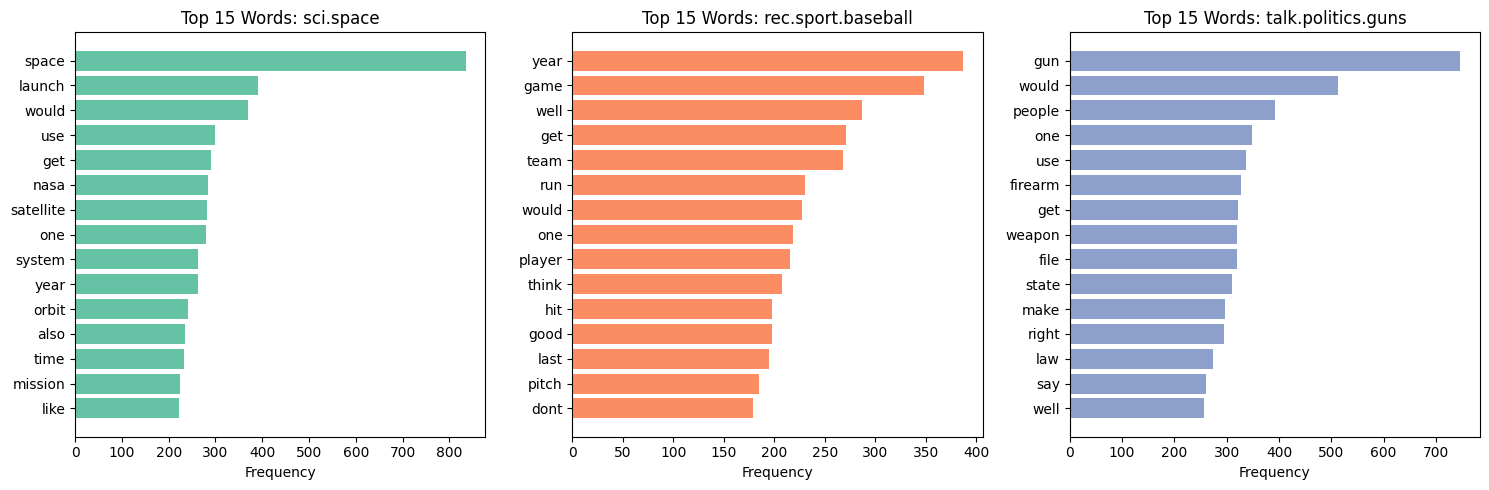

In [52]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)

    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Look at your bar charts above and answer:

1. **What words are UNIQUE to each category?** (List at least 2 per category)
2. **What words are SHARED across categories?** Why do you think they appear in multiple categories?
3. **Based ONLY on the top words, could you guess the topic of each category?** Explain.

**YOUR ANSWER:**

*Category 1 (___):*
- Unique words: ...
-

*Category 2 (___):*
- Unique words: ...
-

*Category 3 (___):*
- Unique words: ...
-

*Shared words and explanation:*
...

*Topic guessing analysis:*
...

### C.2 Word Clouds

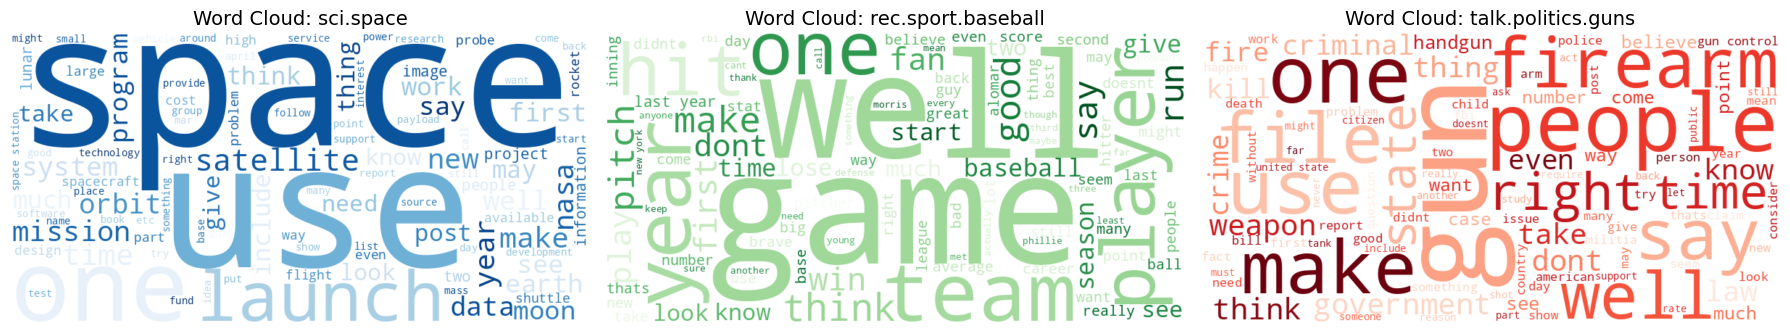

In [53]:
# Simple word cloud for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**.

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

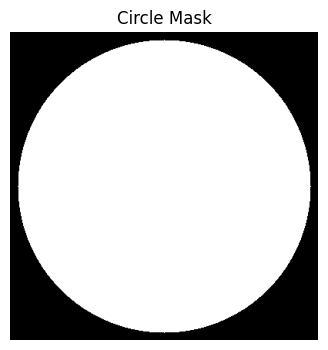

In [54]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

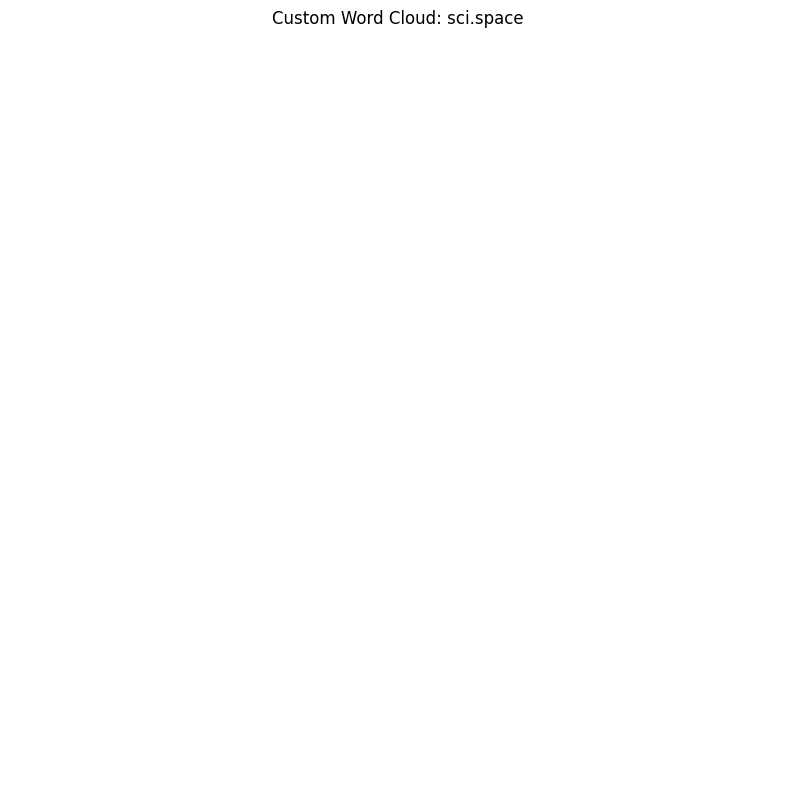

In [55]:
# TODO: Create a custom word cloud with a mask
# Choose ONE of your categories for this visualization

# YOUR CODE HERE
selected_category = "sci.space" # Choose one of your categories

# Get texts for selected category
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

# Create word cloud with mask
# Hint: Use the mask parameter in WordCloud()
# wordcloud = WordCloud(..., mask=your_mask, ...).generate(text_combined)

wordcloud_masked = None  # YOUR CODE HERE

# Display
plt.figure(figsize=(10, 10))
# YOUR CODE HERE - display the wordcloud
plt.title(f'Custom Word Cloud: {selected_category}')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part D: Bag of Words (BoW) Representation

In [56]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

Vocabulary: ['deep' 'great' 'is' 'learning' 'love' 'machine' 'too']

BoW Matrix (dense):
[[0 0 0 1 1 1 0]
 [0 1 1 1 0 1 0]
 [1 0 0 1 1 0 1]]

As DataFrame:


,deep,great,is,learning,love,machine,too
0,0,0,0,1,1,1,0
1,0,1,1,1,0,1,0
2,1,0,0,1,1,0,1


### Exercise D.1: Create BoW for Your Dataset

In [57]:
# TODO: Create a Bag of Words representation for your filtered dataset
# Use parameters: max_features=1000, min_df=5, max_df=0.95

# YOUR CODE HERE
# Create BoW vectorizer with required parameters
bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

# Fit and transform on cleaned texts
bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")

BoW Matrix shape: (1736, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['ability' 'able' 'abuse' 'access' 'accident' 'accord' 'account' 'act'
 'action' 'activity' 'actually' 'add' 'addition' 'address' 'advantage'
 'advertising' 'aerospace' 'age' 'agency' 'agent']


### Exercise D.2: Document Similarity with BoW

In [58]:
from sklearn.metrics.pairwise import cosine_similarity

# TODO: Compute cosine similarity between documents
# Then find the 2 most similar documents and the 2 most different documents

# Compute similarity matrix
similarity_matrix = cosine_similarity(bow_matrix_full)

print(f"Similarity matrix shape: {similarity_matrix.shape}")

Similarity matrix shape: (1736, 1736)


In [59]:
# TODO: Find the 2 most similar documents (excluding self-similarity)
# Hint: Set diagonal to 0 or -1, then find argmax

# YOUR CODE HERE

import numpy as np

# remove self-similarity
np.fill_diagonal(similarity_matrix, -1)

# Find indices of most similar pair
most_similar_idx = np.unravel_index(np.argmax(similarity_matrix), similarity_matrix.shape)  # (idx1, idx2)
most_similar_score = similarity_matrix[most_similar_idx]

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

Most similar documents: (np.int64(697), np.int64(733))
Similarity score: 1.0000000000000002

Document 1 category: sci.space
Document 2 category: sci.space


### Written Question D.1 (Personal Interpretation)

Look at the 2 most similar documents you found:

1. **Are they from the same category or different categories?**
2. **Read the original texts (first 200 characters). What makes them similar?**
3. **Is the BoW similarity measure meaningful here? Why or why not?**

In [60]:
# Show the similar documents for your analysis
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

Document 1 (first 300 chars):
Can someone please remind me who said a well known quotation? 

He was sitting atop a rocket awaiting liftoff and afterwards, in answer to
the question what he had been thinking about, said (approximately) "half a
million components, each has to work perfectly, each supplied by the lowest
bidder....


Document 2 (first 300 chars):
Can someone please remind me who said a well known quotation? 

He was sitting atop a rocket awaiting liftoff and afterwards, in answer to
the question what he had been thinking about, said (approximately) "half a
million components, each has to work perfectly, each supplied by the lowest
bidder....


# **YOUR ANSWER:**

*[Write your analysis here - answer all 3 questions]*

1. Same or different category: ...
The two documents belong to the same category, or at least the same thematic topic. They are identical or nearly identical in content, describing a quotation about a rocket launch and engineering reliability.

2. What makes them similar: ...
They are highly similar because they share:
The exact same sentences
The same vocabulary (rocket, components, liftoff, bidder, etc.)
The same structure and order of words
3. Is BoW meaningful here: ...
In this case, Bag of Words is not very meaningful, because:
It does not detect that the documents are duplicates or near-duplicates explicitly
It only compares word frequency, not meaning or context


---

## Part E: TF-IDF Representation

In [61]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

TF-IDF Matrix:


,deep,great,is,learning,love,machine,too
0,0.000,0.000,0.000,0.481,0.620,0.620,0.000
1,0.000,0.584,0.584,0.345,0.000,0.445,0.000
2,0.584,0.000,0.000,0.345,0.445,0.000,0.584


In [62]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

Word 'learning' scores:
  BoW:    [1, 1, 1]
  TF-IDF: [0.481, 0.345, 0.345]

Notice: TF-IDF gives LOWER scores to common words!


### Exercise E.1: TF-IDF Analysis

In [63]:
# TODO: Create TF-IDF representation for your dataset
# Use same parameters: max_features=1000, min_df=5, max_df=0.95

tfidf_vectorizer_full = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")

TF-IDF Matrix shape: (1736, 1000)


In [64]:
def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""
    # YOUR CODE HERE
    # 1. Get indices of documents in this category
    # 2. Get their TF-IDF vectors
    # 3. Compute mean TF-IDF for each word across these documents
    # 4. Return top n words

    import numpy as np

    # 1. indices of documents in this category
    idx = df_filtered[df_filtered['label_text'] == category].index

    # 2. TF-IDF vectors for these documents
    category_tfidf = tfidf_matrix_full[idx]

    # 3. mean TF-IDF per word
    mean_tfidf = category_tfidf.mean(axis=0).A1  # convert to 1D array

    # 4. get feature names
    feature_names = tfidf_vectorizer_full.get_feature_names_out()

    # 5. top n words
    top_indices = np.argsort(mean_tfidf)[::-1][:n]

    return feature_names[top_indices]

# Display top words for each category
for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f"\nTop TF-IDF words for '{category}':")
    print(top_words)


Top TF-IDF words for 'sci.space':
['space' 'would' 'launch' 'get' 'like' 'one' 'orbit' 'use' 'nasa' 'know']

Top TF-IDF words for 'rec.sport.baseball':
['game' 'year' 'team' 'player' 'run' 'pitch' 'hit' 'baseball' 'well'
 'think']

Top TF-IDF words for 'talk.politics.guns':
['gun' 'would' 'people' 'weapon' 'right' 'dont' 'get' 'make' 'one' 'law']


### Written Question E.1 (Personal Interpretation)

Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
3. **Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.**

**YOUR ANSWER:**

*[Write your comparative analysis here]*

1. Words in TF-IDF but not counts: ...
sci.space: orbit, nasa, launch
rec.sport.baseball: pitch, hit, run
talk.politics.guns: weapon, law, right

2. Words in counts but not TF-IDF: ...
would, one, get, like, know, well

3. Which method is better and why: ...
TF-IDF is more effective than BoW for topic representation because it highlights discriminative words that define each category.


---

## Part F: N-grams and Next Word Prediction

In [65]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]


In [66]:
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


### Exercise F.1: Analyze Bigrams in Your Dataset

In [67]:
bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=500,
    min_df=3
)

# YOUR CODE HERE
# For each category:
# 1. Get the texts
# 2. Fit the bigram vectorizer
# 3. Find most common bigrams

for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()

    # YOUR CODE HERE
    X_bigram = bigram_vectorizer.fit_transform(texts)

    # sum occurrences of each bigram
    bigram_counts = X_bigram.sum(axis=0).A1

    # get bigram names
    bigram_names = bigram_vectorizer.get_feature_names_out()

    # sort by frequency
    sorted_indices = bigram_counts.argsort()[::-1]

    top_bigrams = [(bigram_names[i], bigram_counts[i]) for i in sorted_indices[:15]]

    print(f"\nTop bigrams for '{category}':")
    for bigram, count in top_bigrams[:15]:
        print(f"  {bigram}: {count}")


Top bigrams for 'sci.space':
  space station: 69
  space shuttle: 56
  anonymous ftp: 37
  commercial space: 31
  remote sense: 30
  launch vehicle: 27
  national space: 26
  nasa ames: 24
  air force: 23
  earth orbit: 22
  space technology: 21
  low cost: 21
  black hole: 20
  anyone know: 20
  solar sail: 20

Top bigrams for 'rec.sport.baseball':
  last year: 98
  new york: 49
  home run: 42
  red sox: 33
  dont know: 31
  major league: 25
  dont think: 24
  pitch staff: 22
  world series: 21
  los angeles: 21
  run score: 20
  san francisco: 20
  look like: 19
  san diego: 18
  score run: 18

Top bigrams for 'talk.politics.guns':
  gun control: 110
  united state: 74
  second amendment: 56
  dont know: 34
  dont think: 32
  wait period: 32
  bear arm: 30
  assault weapon: 30
  law enforcement: 29
  gun owner: 29
  keep bear: 27
  homicide rate: 26
  tear gas: 26
  gun law: 23
  main gun: 21


### Exercise F.2: Simple Next Word Predictor

Build a simple next-word predictor using bigram probabilities.

In [68]:
class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}  # {word1: {word2: count, word3: count, ...}}
        self.unigram_counts = {}  # {word: count}

    def train(self, texts):
        """
        Train the model on a list of texts.

        Args:
            texts (list): List of preprocessed text strings
        """
        # YOUR CODE HERE
        # 1. For each text, tokenize into words
        # 2. Count unigrams
        # 3. Count bigrams (word pairs)

        for text in texts:
            words = text.split()

            for i, word in enumerate(words):
                # unigram count
                self.unigram_counts[word] = self.unigram_counts.get(word, 0) + 1

                # bigram count
                if i < len(words) - 1:
                    next_word = words[i + 1]

                    if word not in self.bigram_counts:
                        self.bigram_counts[word] = {}

                    self.bigram_counts[word][next_word] = \
                        self.bigram_counts[word].get(next_word, 0) + 1

    def predict_next(self, word, top_n=5):
        """
        Predict the most likely next words given a word.

        Args:
            word (str): The input word
            top_n (int): Number of predictions to return

        Returns:
            list: List of (next_word, probability) tuples
        """
        # YOUR CODE HERE
        # 1. Look up the word in bigram_counts
        # 2. Calculate probabilities: P(word2|word1) = count(word1, word2) / count(word1)
        # 3. Return top_n predictions sorted by probability

        if word not in self.bigram_counts:
            return []

        next_words = self.bigram_counts[word]
        total_count = self.unigram_counts.get(word, 0)

        if total_count == 0:
            return []

        probabilities = []

        for next_word, count in next_words.items():
            prob = count / total_count
            probabilities.append((next_word, prob))

        probabilities.sort(key=lambda x: x[1], reverse=True)

        return probabilities[:top_n]

# Train on your dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())

In [69]:
# Test your predictor with words relevant to your categories
# TODO: Choose 5 test words that are relevant to YOUR chosen categories

test_words = ["space", "game", "team", "gun", "people"]  # Replace with your words

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")
    for next_word, prob in predictions:
        print(f"  {next_word}: {prob:.3f}")

Next Word Predictions:

'space' ->
  station: 0.082
  shuttle: 0.067
  technology: 0.025
  program: 0.024
  science: 0.021

'game' ->
  era: 0.030
  last: 0.022
  first: 0.022
  year: 0.016
  well: 0.014

'team' ->
  score: 0.034
  get: 0.019
  game: 0.019
  would: 0.019
  baseball: 0.019

'gun' ->
  control: 0.142
  owner: 0.038
  law: 0.030
  ownership: 0.023
  would: 0.017

'people' ->
  dont: 0.036
  would: 0.027
  think: 0.022
  right: 0.017
  kill: 0.017


### Written Question F.1 (Personal Interpretation)

Analyze your next-word predictor results:

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
2. **What are the limitations of this simple bigram model?**
3. **How could you improve this predictor?** (List at least 3 ideas)

**YOUR ANSWER:**

1. Good predictions:
  "space >> station / shuttle" >> very good because it matches the sci.space topic and real-world space vocabulary
"gun >> control / law" >> very good because it reflects the politics.guns category and common expressions like "gun control"
   
   Bad predictions:
"game >> era / last / first" >> not very meaningful, these are generic words and not strongly related to the concept of a game
"people >> kill / would / dont" >>  partially irrelevant or too general; some words are grammatical rather than semantic
2. Limitations: ...
It only considers the previous word, not the full sentence context
It cannot understand meaning or semantics
3. Improvement ideas:
   - ...
   - ...
   - ...

---

## Part G: Document Correlation Matrix

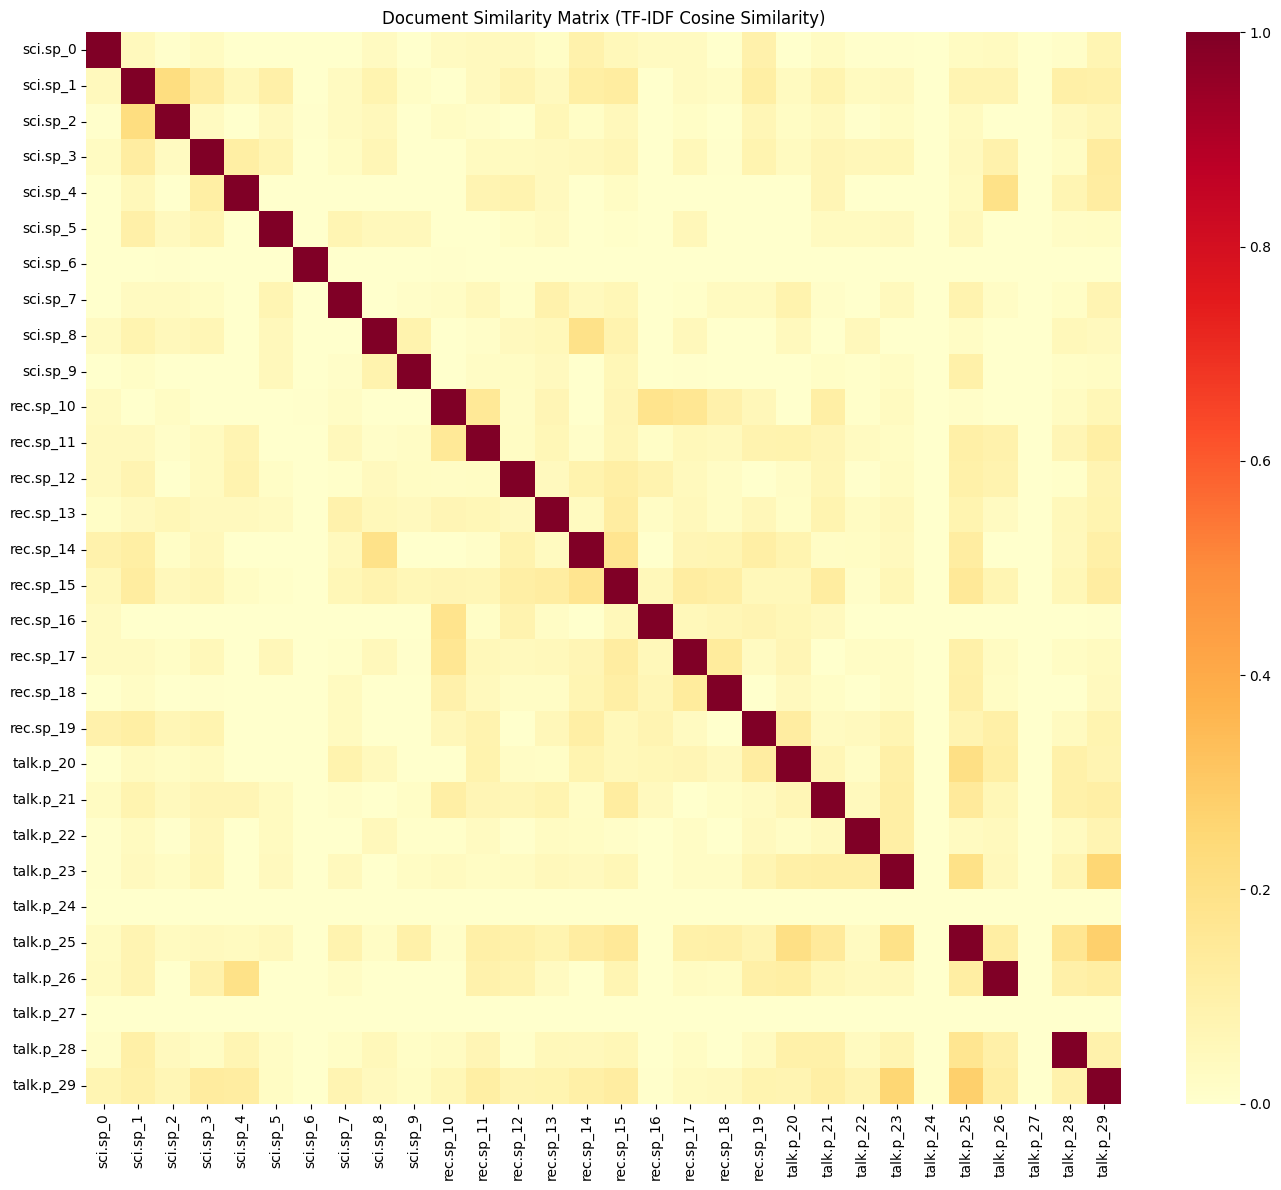

In [70]:
# TODO: Create a correlation/similarity heatmap between documents
# Sample 10 documents from each of your 3 categories (30 total)

import seaborn as sns

# Sample documents
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create labels for heatmap
labels = [f"{cat[:6]}_{i}" for cat, i in zip(df_sampled['label_text'], range(len(df_sampled)))]

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question G.1 (Personal Interpretation)

Analyze the similarity heatmap:

1. **Do documents from the same category cluster together?** (i.e., do you see bright squares along the diagonal for each category group?)
2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?

**YOUR ANSWER:**

1. Clustering observation: ...
Yes, documents from the same category clearly cluster together.
We can observe bright blocks along the diagonal for each group (sci.space, rec.sport.baseball, talk.politics.guns).

2. Most/Least similar category pairs:
most similair : rec.sport.baseball and talk.politics.guns show some moderate cross-similarity in certain areas.
This may be due to shared common vocabulary (e.g. “people”, “would”, “get”), which are generic words used in both topics.
Least similar categories:
sci.space is the most distinct category compared to the others.
It has very specific vocabulary (e.g. “nasa”, “orbit”, “launch”) that does not overlap much with sports or politics.

3. Surprising similarities: ...
Yes, there are some unexpected similarities between different categories.
because These words are not topic-specific but appear frequently across all categories, which increases similarity artificially.


---

## Summary - Part 1

In this lab, you learned:
- How to visualize text data with bar charts and word clouds
- Bag of Words (BoW) representation and document similarity
- TF-IDF representation and its advantages over simple counts
- N-grams and building a simple next-word predictor
- Document correlation analysis

---

## Submission Checklist - Part 1

- [ ] All code exercises completed
- [ ] All written questions answered (with YOUR personal interpretation)
- [ ] Visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Continue to Part 2 for Word Embeddings
